In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import os
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

# RUN184X 

##### (X=6 or 8)

In [25]:
import glob
import pandas as pd
import re

csv_folder = "/scratch/elena/9Li/results/run1848"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))


match = re.search(r'run(\d+)', csv_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filter empty CSVs
            # Add new columns without dropping any existing ones
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)

print(f"Total clusters: {len(df)}")
display(df)

Run number: 1848
Found 48 chunk files
Total clusters: 152443


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,t_window_start_s,t_window_start_rel_ms
0,1.602706e+10,1.622300e+03,52,0,748,"[34, 34, 34, 34, 10, 35, 42, 42, 42, 80, 17, 1...","[78, 78, 78, 78, 61, 76, 80, 80, 80, 30, 29, 2...","[11, 12, 15, 16, 13, 12, 7, 11, 13, 12, 3, 10,...","[11, 4, 5, 14, 12, 4, 2, 11, 12, 4, 18, 10, 3,...","[16027059915.217365, 16027059914.474447, 16027...","[155.0, 46.0, 222.0, 184.0, 151.0, 142.0, 117....",16.027060,0.001622
1,1.602724e+10,1.835959e+05,53,0,748,"[98, 21, 73, 89, 111, 44, 44, 107, 99, 71, 87,...","[100, 64, 31, 89, 97, 43, 43, 44, 90, 103, 88,...","[1, 6, 6, 6, 5, 11, 14, 2, 13, 14, 12, 17, 4, ...","[6, 8, 8, 8, 7, 11, 13, 0, 12, 13, 4, 15, 1, 1...","[16027241887.047194, 16027241883.632421, 16027...","[161.0, 60.0, 137.0, 138.0, 126.0, 167.0, 99.0...",16.027242,0.183596
2,1.602736e+10,2.997140e+05,19,0,748,"[34, 10, 35, 15, 32, 98, 113, 71, 8, 52, 6, 76...","[78, 61, 76, 58, 75, 100, 26, 103, 84, 6, 39, ...","[2, 8, 5, 11, 16, 11, 2, 1, 8, 14, 15, 18, 2, ...","[0, 9, 7, 11, 14, 11, 0, 6, 9, 13, 5, 16, 0, -...","[16027358014.385, 16027357999.608582, 16027358...","[164.0, 151.0, 159.0, 161.0, 129.0, 156.0, 64....",16.027358,0.299714
3,1.602750e+10,4.454266e+05,22,0,748,"[21, 97, 8, 11, 22, 109, 109, 40, 78, 85, 12, ...","[64, 92, 84, 10, 82, 104, 104, 72, 33, 93, 1, ...","[13, 6, 3, 1, 0, 1, 4, 5, 2, 12, 1, 16, 18, 12...","[12, 8, 18, 6, 17, 6, 1, 7, 0, 4, 6, 14, 16, 4...","[16027503710.840342, 16027503711.292385, 16027...","[120.0, 122.0, 162.0, 54.0, 218.0, 129.0, 173....",16.027504,0.445427
4,1.602752e+10,4.578893e+05,45,0,748,"[113, 1, 1, 1, 8, 8, 8, 115, 22, 22, 18, 41, 2...","[26, 70, 70, 70, 84, 84, 84, 57, 82, 82, 69, 4...","[10, 5, 1, 6, 9, 10, 11, 3, 8, 11, 1, 13, 1, 4...","[10, 7, 6, 8, 3, 10, 11, 18, 9, 11, 6, 12, 6, ...","[16027516189.243046, 16027516178.933094, 16027...","[136.0, 338.0, 125.0, 353.0, 194.0, 310.0, 83....",16.027516,0.457889
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152438,2.176112e+12,4.745939e+08,70,55,768,"[103, 99, 10, 16, 16, 47, 47, 47, 47, 34, 17, ...","[98, 90, 61, 73, 73, 13, 13, 13, 13, 78, 29, 2...","[10, 2, 2, 14, 17, 11, 12, 13, 14, 4, 1, 3, 5,...","[10, 0, 0, 13, 15, 11, 4, 12, 13, 1, 6, 18, 7,...","[2176111755552.7056, 2176111755551.8203, 21761...","[96.0, 131.0, 152.0, 137.0, 241.0, 301.0, 197....",2176.111756,474.593878
152439,2.176113e+12,4.759849e+08,19,55,768,"[34, 80, 44, 38, 115, 22, 22, 18, 84, 7, 7, 86...","[78, 30, 43, 65, 57, 82, 82, 69, 87, 34, 34, 1...","[11, 9, 2, 13, 15, 11, 14, 10, 12, 7, 11, 9, 1...","[11, 3, 0, 12, 5, 11, 13, 10, 4, 2, 11, 3, 5, ...","[2176113146558.7244, 2176113146560.9377, 21761...","[91.0, 132.0, 191.0, 120.0, 168.0, 189.0, 172....",2176.113147,475.984888
152440,2.176113e+12,4.761471e+08,18,55,768,"[93, 21, 42, 36, 20, 27, 92, 92, 41, 52, 12, 4...","[101, 64, 80, 46, 81, 2, 25, 25, 49, 6, 1, 21,...","[0, 6, 3, 12, 8, 5, 14, 15, 3, 6, 5, 10, 11, 5...","[17, 8, 18, 4, 9, 7, 13, 5, 18, 8, 7, 10, 11, ...","[2176113308722.217, 2176113308718.0183, 217611...","[157.0, 203.0, 82.0, 165.0, 183.0, 122.0, 152....",2176.113309,476.147056
152441,2.176114e+12,4.765548e+08,65,55,768,"[36, 36, 34, 25, 25, 25, 25, 17, 17, 17, 17, 2...","[46, 46, 78, 62, 62, 62, 62, 29, 29, 29, 29, 8...","[9, 10, 14, 10, 13, 14, 17, 7, 10, 9, 11, 3, 5...","[3, 10, 13, 10, 12, 13, 15, 2, 10, 3, 11, 18, ...","[2176113716510.8274, 2176113716509.9534, 21761...","[158.0, 191.0, 140.0, 169.0, 221.0, 238.0, 222...",2176.113717,476.554841


In [26]:
activity_df = df.drop_duplicates(subset=['spill_id'])[['spill_id', 'nCLusters_in_spill']]
print(activity_df)

        spill_id  nCLusters_in_spill
0              0                 748
748            1                 517
1265           2                 520
1785           3                 489
2274           4                 500
...          ...                 ...
150105        50                  12
150117        51                 514
150631        52                 547
151178        53                 491
151669        54                   6

[254 rows x 2 columns]


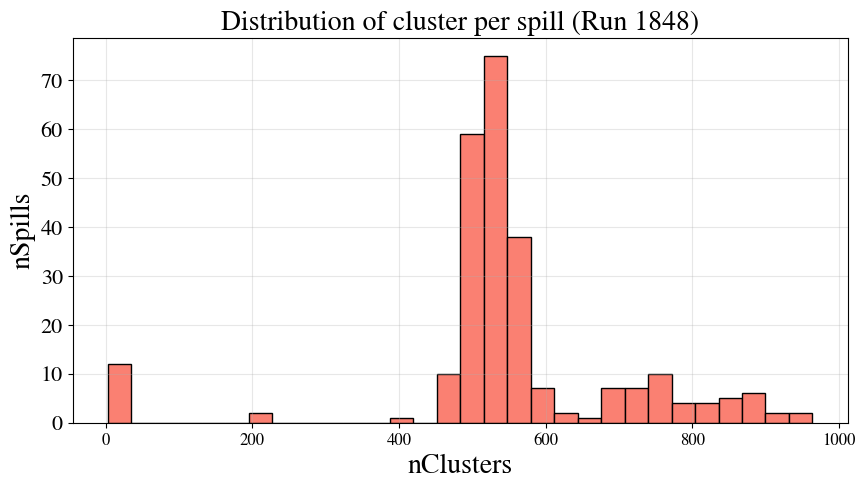

Total Clusters found in these spills: 139508
Average Clusters per 'Active' Spill: 549.24


In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(activity_df['nCLusters_in_spill'], bins=30, color='salmon', edgecolor='black')
plt.title(f"Distribution of cluster per spill (Run {run_number})")
plt.xlabel("nClusters")
plt.ylabel("nSpills")
plt.grid(alpha=0.3)
plt.show()

print(f"Total Clusters found in these spills: {activity_df['nCLusters_in_spill'].sum()}")
print(f"Average Clusters per 'Active' Spill: {activity_df['nCLusters_in_spill'].mean():.2f}")

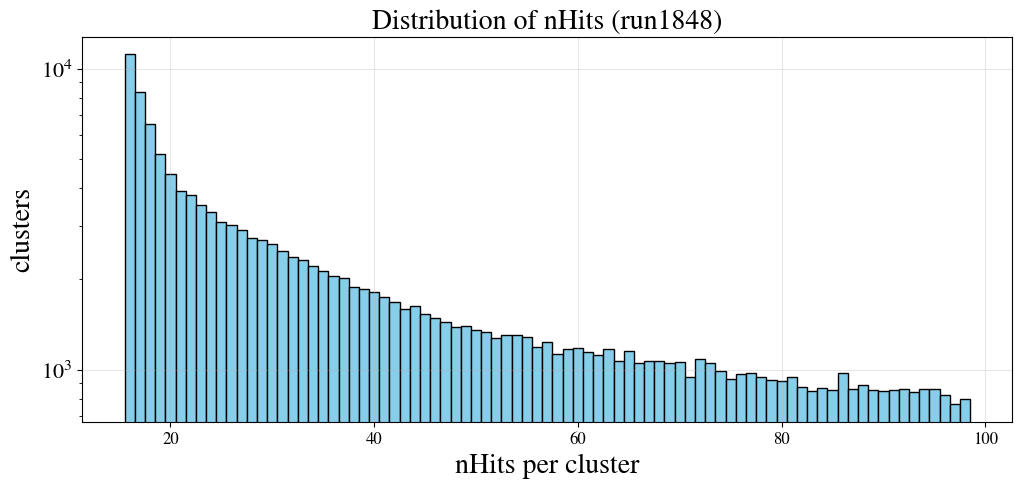

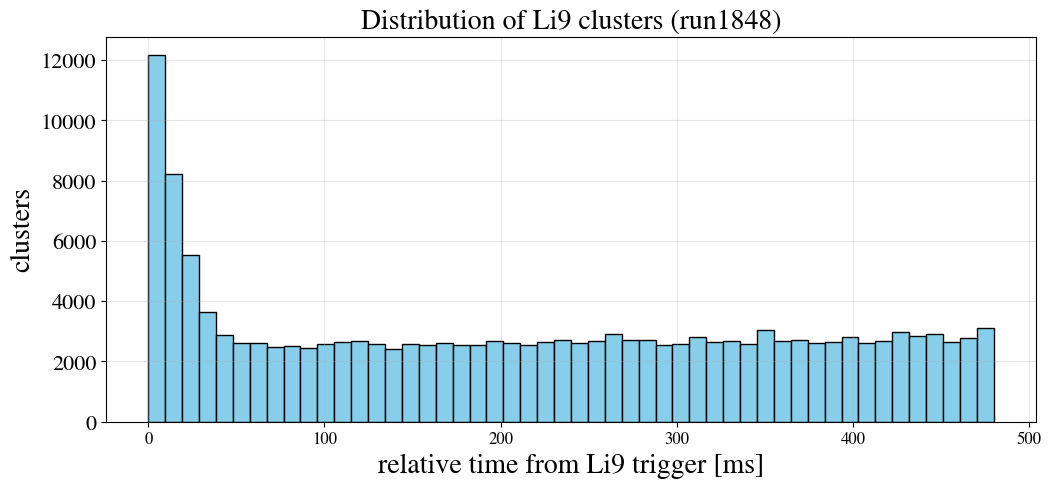

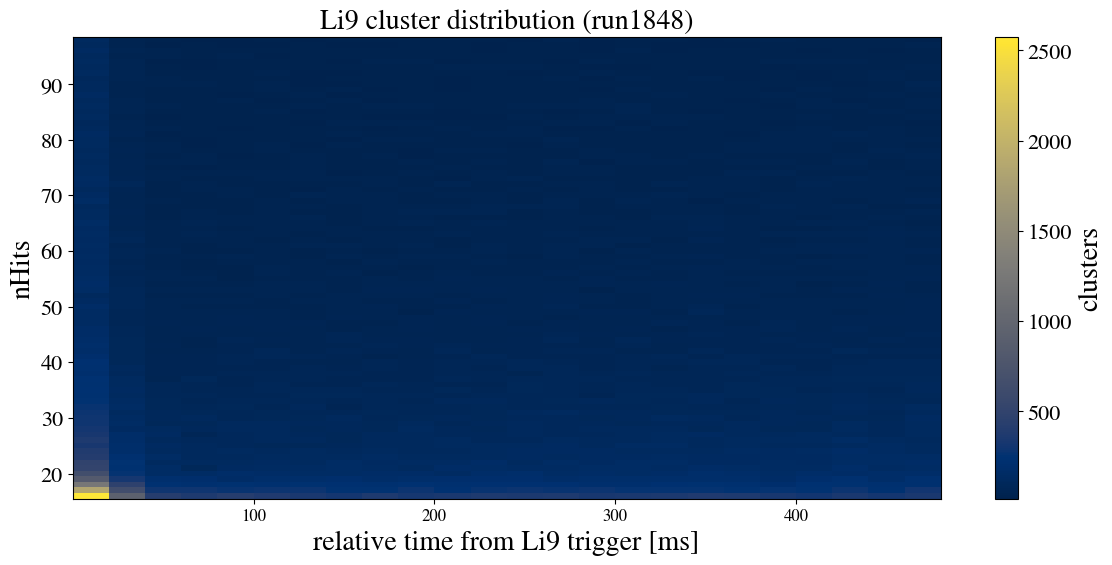

In [28]:
# -------------------------
# 2. 1D Histograms
# -------------------------

# Histogram: nHits per cluster
plt.figure(figsize=(12,5))
n_bins = np.arange(df['nHits'].min(), df['nHits'].max()+2) - 0.5            # +2 ensures the top-most value lands in a bin, the -0.5 centers bins on integers.
plt.hist(df['nHits'], bins=n_bins, color='skyblue', edgecolor='black')      #that's why we were missing the peak @ 40 before (only +1)
plt.yscale("log")
plt.xlabel("nHits per cluster")
plt.ylabel("clusters")
plt.title(f"Distribution of nHits (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram: relative time from Li9 window start
plt.figure(figsize=(12,5))
plt.hist(df['t_window_start_rel_ms'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("clusters")
plt.title(f"Distribution of Li9 clusters (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 3. 2D Histogram / Heatmap
# -------------------------

x = df['t_window_start_rel_ms']
y = df['nHits']

# Binning
x_bins = np.linspace(x.min(), x.max(), 25)       # finer bins for time
y_bins = np.arange(y.min()-0.5, y.max()+1.5, 1)  # integer nHits bins

H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

plt.figure(figsize=(14,6))
plt.pcolormesh(xedges, yedges, H.T, cmap='cividis', shading='auto')
plt.colorbar(label='clusters')
plt.xlabel('relative time from Li9 trigger [ms]')
plt.ylabel('nHits')
plt.title(f'Li9 cluster distribution (run{run_number})')
plt.show()